In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os 
from pathlib import Path
import torch 

import m2aia as m2
from ims_contrastive_model import IMSPyTorchDataset, IMSContrastiveModel 
from ims_contrastive_model.utils.Binners import LinearBinning, NotEmptyInverseBinner, TopPeaksInverseBinner

# seting global dir
cwd=Path.cwd()
if cwd.name == "tutorials":
    # os.chdir(cwd.parent.parent) 
    os.chdir(cwd.parent) 
os.getcwd()

'/home/maxi7524/repositories/pym2aia_test'

In [2]:
# data loading 
PATH_DATA = Path('data')
PATH_real_data = PATH_DATA / 'bladder_data' / 'mouse_urinary_bladder.imzML'
print(PATH_real_data.exists())

# load data - IMPORTANT (NEED TO PASS STR)
I = m2.ImzMLReader(
    str(PATH_real_data),
    # We assume tic normalization
    normalization=m2.m2NormalizationTIC
)

True
!Tue May  5 08:01:44 2026 
6.584! WARNING: No pixel size found, set x and y spacing to 50 microns!
!10.008! WARNING: Processed profile spectrum is not fully supported! Check the ImzML file.
[10.832] [imzML]: data/bladder_data/mouse_urinary_bladder.imzML
	[pixel size (mm)]: 0.050000x0.050000x0.010000
	[image dimension]: 260x134x1
	[num spectra]: 34840
	[spec. type]: ProcessedProfile
	[mass range]: 400.259620 to 999.795899 with #1500 measurements
	[normalization]: TIC


In [3]:
# instantiation model|
model_path = PATH_DATA / 'bladder_data' / 'model_new'
## new model takes much more data
model = IMSContrastiveModel(path=model_path, epochs=10,batch_size=128)

Model will be loaded on cuda


In [4]:
model.load()

[Load]: Model loaded successfully from data/bladder_data/model_new


In [4]:
# create new model

# creating dataset
# TODO this name is misleading - it is formally dataset
xs_res = I.GetSpacing()[2]
## i round values to max spacing to obtain 'nice' numbers, and i want to consider first and last numbers
xs_min = np.round(I.GetXAxis()[0] - xs_res, int(- np.log10(xs_res)))
xs_max = np.round(I.GetXAxis()[-1] + xs_res, int(- np.log10(xs_res)))
Binner = LinearBinning(
    xs_min=np.round(I.GetXAxis()[0]),
    xs_max=np.ceil(I.GetXAxis()[-1]),
    xs_res=xs_res,
)
# REMARKS - it can be unusable if model is not decoding well enough
# InverseBinner = NotEmptyInverseBinner(Binner)
InverseBinner = TopPeaksInverseBinner(Binner, max_bins=1500)

loader = IMSPyTorchDataset(m2aia_img=I, Binner=Binner)
model.define_model(latent_dim=300, IMSLoader=loader, InverseBinner=InverseBinner)

[IMSContrastiveModel]: Initialization of new model ... 
[Optimization] Estimated peak envelope width: 25 bins


In [6]:
model._hyperparameters

{'input_dim': 60001,
 'latent_dim': 300,
 'channels': [1, 2, 4, 16, 32, 64],
 'kernels': [7, 7, 5, 5, 5],
 'strides': [2, 3, 3, 3, 3]}

In [ ]:
# ~3 min for 2 peaks 
model.fit()

Building noise bank (max 2 peaks per spectrum)...
PeakBank created with 69680 total noise samples.

--- Epoch 1/10 ---
[  5%] 1792/34840 pixels processed | Loss: 0.2831 | ETA: 1.8 min
[ 10%] 3584/34840 pixels processed | Loss: 0.2320 | ETA: 1.4 min
[ 15%] 5376/34840 pixels processed | Loss: 0.2002 | ETA: 1.0 min
[ 21%] 7168/34840 pixels processed | Loss: 0.1746 | ETA: 0.9 min
[ 26%] 8960/34840 pixels processed | Loss: 0.1542 | ETA: 0.9 min
[ 31%] 10752/34840 pixels processed | Loss: 0.1376 | ETA: 0.8 min
[ 36%] 12544/34840 pixels processed | Loss: 0.1236 | ETA: 0.8 min
[ 41%] 14336/34840 pixels processed | Loss: 0.1121 | ETA: 0.7 min
[ 46%] 16128/34840 pixels processed | Loss: 0.1026 | ETA: 0.6 min
[ 51%] 17920/34840 pixels processed | Loss: 0.0957 | ETA: 0.6 min
[ 57%] 19712/34840 pixels processed | Loss: 0.0918 | ETA: 0.5 min
[ 62%] 21504/34840 pixels processed | Loss: 0.0878 | ETA: 0.4 min
[ 67%] 23296/34840 pixels processed | Loss: 0.0852 | ETA: 0.4 min
[ 72%] 25088/34840 pixels pr

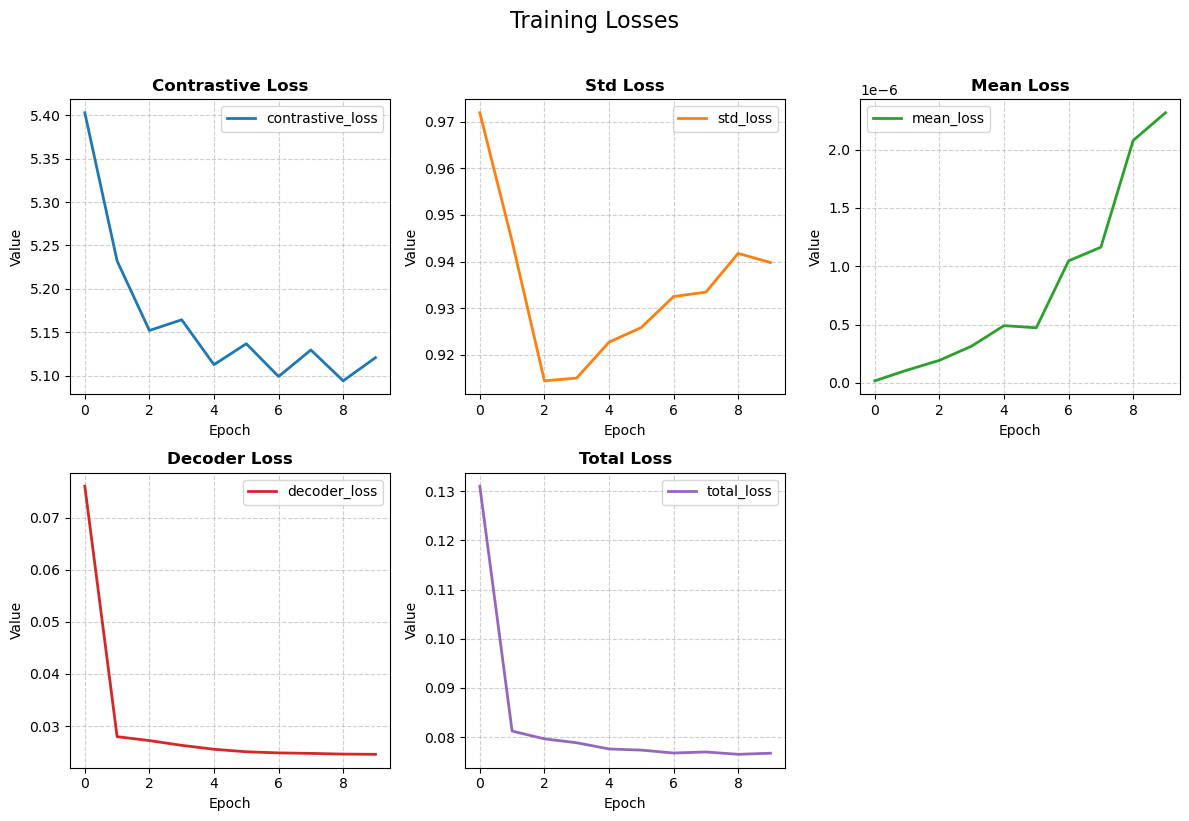

In [6]:
model.plot_epoch_losses()

In [ ]:
path_name_new_compressed = PATH_DATA / 'bladder_data' / 'mouse_bladder_modified_noise.npz'
model.compress_to_file(path_name_new_compressed)

[Model] Encoding image to latent space...


[Model] Done encoding image.
[Model] Compression complete. Saved to: data/bladder_data/mouse_bladder_modified_noise.npz


: 

In [6]:
path_name_new_compressed = PATH_DATA / 'bladder_data' / 'mouse_bladder_modified_noise.npz'
path_name_new_imzML_file = PATH_DATA / 'bladder_data' / 'mouse_bladder_modified_noise_reconstruct'

model.reconstruct_from_file(path_name_new_compressed, path_name_new_imzML_file)

[Model] Reconstructing image from data/bladder_data/mouse_bladder_modified_noise.npz...
[Model] Reconstructing 34840 spectra using batch processing...
[  5%] 1792/34840 pixels processed | ETA: 3.0 min
[ 10%] 3584/34840 pixels processed | ETA: 2.8 min
[ 15%] 5376/34840 pixels processed | ETA: 2.4 min
[ 21%] 7168/34840 pixels processed | ETA: 2.3 min
[ 26%] 8960/34840 pixels processed | ETA: 2.2 min
[ 31%] 10752/34840 pixels processed | ETA: 2.0 min
[ 36%] 12544/34840 pixels processed | ETA: 1.9 min
[ 41%] 14336/34840 pixels processed | ETA: 1.7 min
[ 46%] 16128/34840 pixels processed | ETA: 1.5 min
[ 51%] 17920/34840 pixels processed | ETA: 1.4 min
[ 57%] 19712/34840 pixels processed | ETA: 1.3 min
[ 62%] 21504/34840 pixels processed | ETA: 1.1 min
[ 67%] 23296/34840 pixels processed | ETA: 0.9 min
[ 72%] 25088/34840 pixels processed | ETA: 0.8 min
[ 77%] 26880/34840 pixels processed | ETA: 0.7 min
[ 82%] 28672/34840 pixels processed | ETA: 0.5 min
[ 87%] 30464/34840 pixels processed | 

In [3]:
path_name_new_imzML_file = PATH_DATA / 'bladder_data' / 'mouse_bladder_modified_noise_reconstruct'

# original data
I_original = I

# autoencoded data
PATH_autoencoded_data = Path(str(path_name_new_imzML_file) + '.imzML')
I_autoencoded =  m2.ImzMLReader(str(PATH_autoencoded_data))



!10.842! WARNING: No pixel size found, set x and y spacing to 50 microns!
[18.762] [imzML]: data/bladder_data/mouse_bladder_modified_noise_reconstruct.imzML
	[pixel size (mm)]: 0.050000x0.050000x0.010000
	[image dimension]: 260x134x1
	[num spectra]: 34840
	[spec. type]: ProcessedCentroid
	[mass range]: 400.502811 to 999.219998 with #1490 measurements


In [8]:
import napari


# 1. Fix graphical rendering issues for WSL/Remote environments
os.environ['LIBGL_ALWAYS_SOFTWARE'] = '1'

def get_reshaped_ion_image(reader, mz, tolerance):
    """
    Helper to fetch an ion image from m2aia and reshape it to (z, y, x)
    """
    nx, ny, nz = reader.GetShape()
    # GetImage returns an m2aia object, cast to numpy and reshape
    img_data = np.array(reader.GetImage(mz, tolerance))
    return img_data.reshape((nz, ny, nx))

# 2. Load two separate images for comparison
# Assuming I_loaded is your first image, let's define a second one
# reader1 = I_loaded
# reader2 = m2.ImzMLReader("path_to_second_file.imzML")
# reader2.Load()

reader1 = I_original
# For demonstration, I will use the same reader as reader2 if you only have one loaded
reader2 = I_autoencoded

# 3. Initial parameters
target_mz = 800.5
tolerance = 0.1

# 4. Initialize Napari Viewer
viewer = napari.Viewer()

# 5. Load initial ion images for both datasets
ion1 = get_reshaped_ion_image(reader1, target_mz, tolerance)
ion2 = get_reshaped_ion_image(reader2, target_mz, tolerance)

layer1 = viewer.add_image(ion1, name='Dataset A', colormap='magma')
layer2 = viewer.add_image(ion2, name='Dataset B', colormap='magma')

# 6. Enable Grid View for side-by-side comparison
# This puts the images next to each other instead of overlapping
viewer.grid.enabled = True
viewer.grid.shape = (1, 2) # 1 row, 2 columns

# 7. Interactive M/Z Update Function
def update_mz(mz):
    """
    Call this function in a new notebook cell to change the mass on both images
    Example: update_mz(760.4)
    """
    print(f"Updating images to {mz} m/z...")
    layer1.data = get_reshaped_ion_image(reader1, mz, tolerance)
    layer2.data = get_reshaped_ion_image(reader2, mz, tolerance)
    layer1.name = f'A: {mz} m/z'
    layer2.name = f'B: {mz} m/z'

# 8. Add Masks if available
try:
    nx1, ny1, nz1 = reader1.GetSize()
    mask1 = np.array(reader1.GetMaskImage()).reshape((nz1, ny1, nx1))
    viewer.add_labels(mask1.astype(int), name='Mask A', opacity=0.2)
    
    nx2, ny2, nz2 = reader2.GetSize()
    mask2 = np.array(reader2.GetMaskImage()).reshape((nz2, ny2, nx2))
    viewer.add_labels(mask2.astype(int), name='Mask B', opacity=0.2)
except Exception as e:
    print(f"No masks loaded: {e}")

# To browse a new mass, simply run this in the next cell:
# update_mz(742.5)

No masks loaded: 'ImzMLReader' object has no attribute 'GetSize'


In [4]:
from ims_contrastive_model.utils.VisualizationInteractive import M2AIAExplorer, M2AIAMultiExplorer

In [5]:
interactive = M2AIAExplorer(I_autoencoded)

In [6]:
interactive.plot()

In [7]:
# r1 = m2.ImzMLReader("sample1.imzML")
# r2 = m2.ImzMLReader("sample2.imzML")
explorer = M2AIAMultiExplorer([I, I_autoencoded], labels=["Original", "Autoencoded"])

In [8]:
explorer.plot()

ValueError: ('Center is out of x-axis range!', np.float64(400.2596199440525), 0.1, <class 'numpy.float32'>, False)

ValueError: ('Center is out of x-axis range!', np.float64(999.7958993022552), 0.1, <class 'numpy.float32'>, False)